In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import Perceptron
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical


In [58]:
import sys
!{sys.executable} -m pip install kagglehub


In [59]:
import kagglehub

path = kagglehub.dataset_download("oddrationale/mnist-in-csv")
print(path)

C:\Users\mansi\.cache\kagglehub\datasets\oddrationale\mnist-in-csv\versions\2


In [60]:
import os

path = r"C:\Users\mansi\.cache\kagglehub\datasets\oddrationale\mnist-in-csv\versions\2"
print(os.listdir(path))

['mnist_test.csv', 'mnist_train.csv']


In [61]:
df_train = pd.read_csv(os.path.join(path, "mnist_train.csv"))
df_test = pd.read_csv(os.path.join(path, "mnist_test.csv"))

In [62]:
df_train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
df_train.shape

(60000, 785)

In [64]:
#Preprocessing the data
X_train = df_train.drop("label", axis=1)
y_train = df_train["label"]
X_test = df_test.drop("label", axis=1)
y_test = df_test["label"]

In [65]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

In [66]:
X_train_img=X_train.values.reshape(-1,28,28)
X_test_img=X_test.values.reshape(-1,28,28)

In [67]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [68]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [69]:
Perceptron_model = Sequential({
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
})

In [70]:
Perceptron_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [71]:
history=Perceptron_model.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat),verbose=1)

Epoch 1/5


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(32, 10), output.shape=(32, 280)

In [ ]:
acc_percep=Perceptron_model.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [ ]:
acc_percep

0.9100000262260437

In [ ]:
Ann_model=Sequential({
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
})

In [ ]:
Ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [79]:
history_ann=Ann_model.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9841 - loss: 0.0526 - val_accuracy: 0.9645 - val_loss: 0.1315
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9851 - loss: 0.0475 - val_accuracy: 0.9674 - val_loss: 0.1289
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9857 - loss: 0.0442 - val_accuracy: 0.9685 - val_loss: 0.1314
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9873 - loss: 0.0401 - val_accuracy: 0.9670 - val_loss: 0.1375
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9883 - loss: 0.0369 - val_accuracy: 0.9650 - val_loss: 0.1469


In [ ]:
accuracy = Ann_model.evaluate(X_test_img, y_test_cat,verbose=0)[1]

In [ ]:
accuracy

0.9688000082969666

In [ ]:
X_train_cnn=X_train_img.reshape(-1,28,28,1)
X_test_cnn=X_test_img.reshape(-1,28,28,1)

In [ ]:
Cnn_model=Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
     

In [ ]:
Cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [75]:
history_cnn=Cnn_model.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9940 - loss: 0.0193 - val_accuracy: 0.9929 - val_loss: 0.0266
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9943 - loss: 0.0180 - val_accuracy: 0.9915 - val_loss: 0.0323
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9947 - loss: 0.0167 - val_accuracy: 0.9920 - val_loss: 0.0324
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9948 - loss: 0.0155 - val_accuracy: 0.9929 - val_loss: 0.0252
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9952 - loss: 0.0143 - val_accuracy: 0.9932 - val_loss: 0.0307


In [ ]:
accuracy=Cnn_model.evaluate(X_test_cnn, y_test_cat,verbose=0)[1]

In [ ]:
accuracy

0.9919000267982483

In [72]:

def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

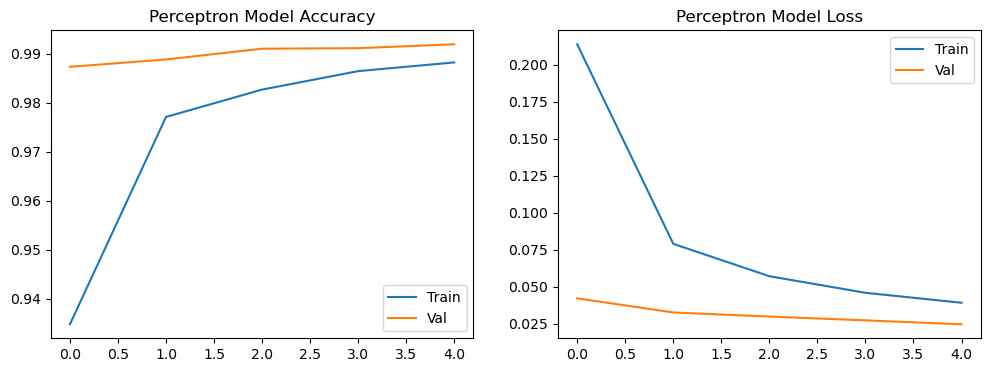

In [77]:
plot_training(history, "Perceptron Model")

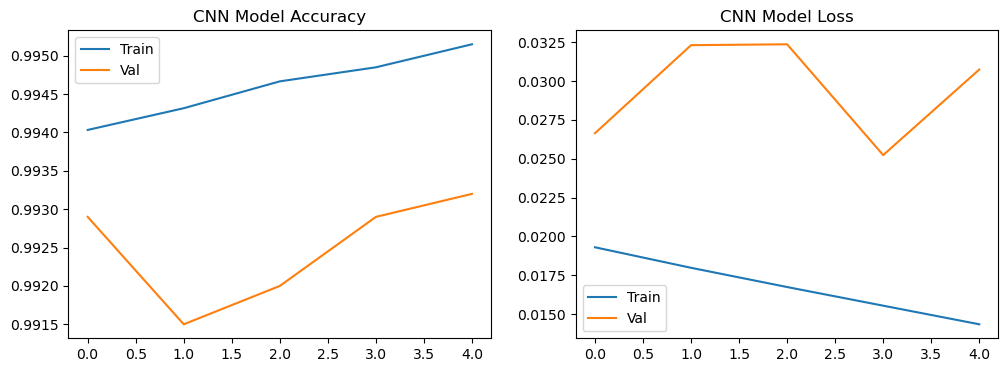

In [76]:
plot_training(history_cnn, "CNN Model")

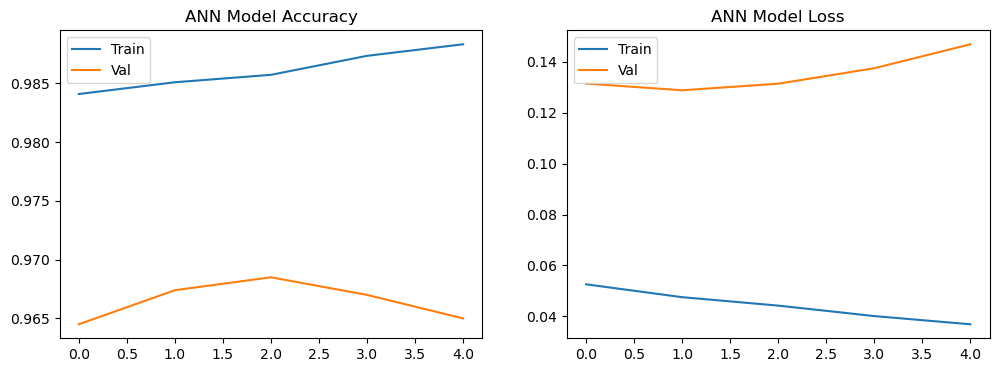

In [81]:
plot_training(history_ann, "ANN Model")